# Lab 1: MLP Regression & Classification

**Name:** *(replace with your name)*

Part 1 continues directly from what you already built — same dataset, same one-hot encoding approach, a regression MLP. Parts 2 and 3 apply that same MLP-building pattern to a new problem type: classification instead of regression. Watch closely for exactly which pieces of the code change, and which stay identical.

## Setup — Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

### Shared helper: plotting loss (and accuracy, when available)

We'll reuse this for all three parts so the curves are directly comparable.

In [2]:
def plot_history(history, title, show_accuracy=False):
    if show_accuracy:
        fig, axes = plt.subplots(1, 2, figsize=(11, 4))
        axes[0].plot(history.history["loss"], label="Training Loss")
        axes[0].plot(history.history["val_loss"], label="Validation Loss")
        axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].legend()
        axes[0].set_title(title + " -- Loss")

        axes[1].plot(history.history["accuracy"], label="Training Accuracy")
        axes[1].plot(history.history["val_accuracy"], label="Validation Accuracy")
        axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].legend()
        axes[1].set_title(title + " -- Accuracy")
        plt.tight_layout()
        plt.show()
    else:
        plt.figure(figsize=(6, 4))
        plt.plot(history.history["loss"], label="Training Loss")
        plt.plot(history.history["val_loss"], label="Validation Loss")
        plt.xlabel("Epoch"); plt.ylabel("Loss (MSE, scaled)"); plt.title(title); plt.legend()
        plt.show()

---
# Part 1 — Regression with One-Hot Encoding (Ames Housing)

In [3]:
ames = fetch_openml(name="house_prices", as_frame=True, parser="auto")
df = ames.frame
df = df[["GrLivArea", "OverallQual", "YearBuilt", "TotalBsmtSF", "GarageCars",
        "Neighborhood", "HouseStyle", "MSZoning", "SalePrice"]].dropna()

categorical_features = ["Neighborhood", "HouseStyle", "MSZoning"]

# One-hot encode
df_onehot = pd.get_dummies(df, columns=categorical_features, drop_first=True)

# Spilt the data into Features and Target Variables
X1 = df_onehot.drop(columns=["SalePrice"]).values.astype(float)
y1 = df_onehot["SalePrice"].values.astype(float)

# Print the shape of feature matrix
print("Feature matrix shape:", X1.shape)

Feature matrix shape: (1460, 40)


In [4]:
X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.2, random_state=42
)

x1_scaler = StandardScaler()
X1_train_scaled = x1_scaler.fit_transform(X1_train)
X1_test_scaled = x1_scaler.transform(X1_test)

y1_scaler = StandardScaler()
y1_train_scaled = y1_scaler.fit_transform(y1_train.reshape(-1, 1)).flatten()
y1_test_scaled = y1_scaler.transform(y1_test.reshape(-1, 1)).flatten()

**Build your MLP.** Fill in the blanks (`___`) and be ready to justify your choices.

In [5]:
model_reg = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation="relu", input_shape=(X1_train_scaled.shape[1],)),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(1)
])

model_reg.compile(optimizer="adam", loss="mse", metrics=["mae"])

# Q: Why does the output layer have no activation function?
# Your answer: Since we are using a regression model, there is no need for an activation function in the output layer.


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


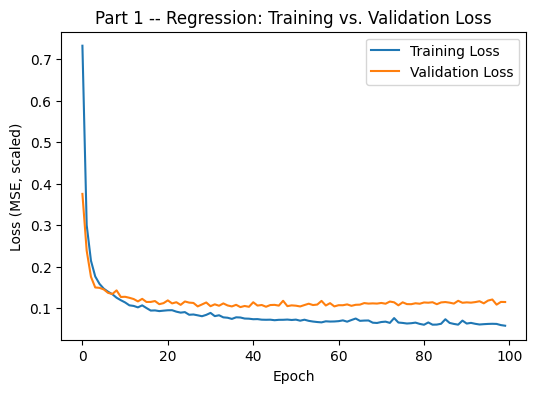

In [6]:
history_reg = model_reg.fit(
    X1_train_scaled, y1_train_scaled,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=0
)

plot_history(history_reg, "Part 1 -- Regression: Training vs. Validation Loss")

**Diagnose:** good fit, overfitting, or underfitting? Write 1–2 sentences.

*Your answer:* This graph shows a good fit of the training loss. Since the loss is steadily going down on both the training and validation loss it is a good fit.


In [7]:
preds_scaled = model_reg.predict(X1_test_scaled).flatten()
preds_dollars = y1_scaler.inverse_transform(preds_scaled.reshape(-1, 1)).flatten()

rmse_reg = np.sqrt(np.mean((preds_dollars - y1_test) ** 2))
mae_reg = np.mean(np.abs(preds_dollars - y1_test))

print(f"Part 1 -- Test RMSE: ${rmse_reg:,.0f}")
print(f"Part 1 -- Test MAE:  ${mae_reg:,.0f}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Part 1 -- Test RMSE: $30,408
Part 1 -- Test MAE:  $19,944


---
# Part 2 — Binary Classification (Pima Indians Diabetes)

Predicting whether a patient has diabetes (1) or not (0) from 8 medical measurements.

In [9]:
diabetes = fetch_openml(name="diabetes", version=1, as_frame=True, parser="auto")
df2 = diabetes.frame

print(df2.shape)
print(df2["class"].value_counts())

# Q: How many classes? Is this dataset balanced or imbalanced?
# Your answer: There are two classes being tested_negative and tested_positive. This dataset is imbalanced because there are almost double the amount of people in the tested_negative class as opposed to the tested_positive class.


(768, 9)
class
tested_negative    500
tested_positive    268
Name: count, dtype: int64


In [ ]:
X2 = df2.drop(columns=["class"]).values.astype(float)
y2 = (df2["class"] == "tested_positive").astype(int).values

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2
)

# Q: Why stratify here? Why did Part 1 not need this?
# Your answer:

x2_scaler = StandardScaler()
X2_train_scaled = x2_scaler.fit_transform(X2_train)
X2_test_scaled = x2_scaler.transform(X2_test)

# Note: y2 is NOT scaled here.
# Q: Why not, compared to Part 1's y1_scaler?
# Your answer:


**Build your MLP.** Fill in the blanks — this time there are two new ones: the output activation, and the loss function.

In [ ]:
# Create the classification model
model_binary = tf.keras.Sequential([
])

model_binary.compile(optimizer="", loss="", metrics=["accuracy"])

# Q: What output activation did you use, and why does it fit a yes/no prediction?
# Your answer:

# Q: What loss function did you use, and how does it relate to what "sigmoid" outputs?
# Your answer:


In [ ]:
history_binary = model_binary.fit(
    X2_train_scaled, y2_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=0
)

plot_history(history_binary, "Part 2 -- Binary Classification", show_accuracy=True)

**Diagnose:** good fit, overfitting, or underfitting? Write 1–2 sentences.

*Your answer:*


In [ ]:
binary_preds = (model_binary.predict(X2_test_scaled).flatten() >= 0.5).astype(int)

acc_binary = accuracy_score(y2_test, binary_preds)
print(f"Part 2 -- Test Accuracy: {acc_binary:.3f}")

cm = confusion_matrix(y2_test, binary_preds)
ConfusionMatrixDisplay(cm, display_labels=["No Diabetes", "Diabetes"]).plot()
plt.title("Part 2 -- Confusion Matrix")
plt.show()

# Q: In a medical diagnosis context, are false positives and false negatives
# equally costly? Which would you rather minimize, and why? How might that
# change the 0.5 threshold you'd choose?
# Your answer:


---
# Part 3 — Multiclass Classification (Wine Quality)

Raw wine quality scores are heavily imbalanced at the extremes, so we bucket them into
3 broader bands to make this a genuine, learnable multiclass problem.

In [ ]:
wine = fetch_openml(name="wine-quality-red", version=1, as_frame=True, parser="auto")
df3 = wine.frame

print(df3.shape)
print(df3["class"].astype(int).value_counts().sort_index())

In [ ]:
# Bucket raw quality scores into 3 bands: low / medium / high
def bucket_quality(q):
    q = int(q)
    if q <= 5:
        return 0  # low
    elif q == 6:
        return 1  # medium
    else:
        return 2  # high

df3["quality_band"] = df3["class"].apply(bucket_quality)
print(df3["quality_band"].value_counts().sort_index())

# Q: How many classes do we have now? Are they reasonably balanced?
# Your answer:


**Encode your labels.** We'll use integer labels (0, 1, 2) with `sparse_categorical_crossentropy` — this avoids a separate one-hot encoding step for the labels. (An equally valid alternative: one-hot encode the labels with `to_categorical` and use plain `categorical_crossentropy` instead — same result, different bookkeeping.)

In [ ]:
X3 = df3.drop(columns=["class", "quality_band"]).values.astype(float)
y3 = df3["quality_band"].values.astype(int)

X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y3, test_size=0.2, random_state=42, stratify=y3
)

x3_scaler = StandardScaler()
X3_train_scaled = x3_scaler.fit_transform(X3_train)
X3_test_scaled = x3_scaler.transform(X3_test)

**Build your MLP.** This time, fill in the number of output neurons too — it's no longer fixed at 1.

In [ ]:
n_classes = len(np.unique(y3))

# Create the classification model
model_multi = tf.keras.Sequential()

model_multi.compile(optimizer= "", loss="", metrics=[""])

# Q: How many output neurons did you use, and why is that number tied to n_classes?
# Q: What activation function turns raw outputs into class probabilities that sum to 1?
# Your answers:


In [ ]:
history_multi = model_multi.fit(
    X3_train_scaled, y3_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=0
)

plot_history(history_multi, "Part 3 -- Multiclass Classification", show_accuracy=True)

**Diagnose:** good fit, overfitting, or underfitting? Write 1–2 sentences.

*Your answer:*


In [ ]:
multi_probs = model_multi.predict(X3_test_scaled)
multi_preds = np.argmax(multi_probs, axis=1)

acc_multi = accuracy_score(y3_test, multi_preds)
print(f"Part 3 -- Test Accuracy: {acc_multi:.3f}")

cm3 = confusion_matrix(y3_test, multi_preds)
ConfusionMatrixDisplay(cm3, display_labels=["Low", "Medium", "High"]).plot()
plt.title("Part 3 -- Confusion Matrix")
plt.show()

# Q: Which classes does your model confuse most often? Does that make sense
# given how the quality bands were constructed?
# Your answer:


---
# Comparison & Reflection

Fill in from your own three models:

| | Part 1 (Regression) | Part 2 (Binary) | Part 3 (Multiclass) |
|---|---|---|---|
| Output neurons | | | |
| Output activation | | | |
| Loss function | | | |
| Label format | | | |
| Evaluation metric(s) | | | |

**Write 4–5 sentences:**

1. What's the general rule connecting the *number of classes* to the *number of output neurons* and the *choice of activation*?
2. Why doesn't regression need an activation function on the output, while both classification tasks do?
3. For Part 3: why might accuracy alone be a misleading metric if your class counts are imbalanced?

*Your answer:*



---
## Done!

Save this notebook back to your GitHub fork, then submit your two links on Canvas.